In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('bank-full.csv' , sep = ';')

In [3]:
# Shape of dataset
df.shape

(45211, 17)

In [4]:
#Discovering the type of each column
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


In [5]:
#Identifying Numeric columns with their Names
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Columns:")
print(list(numeric_cols))

# #Identifying Categorical columns with their Names
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical Columns:")
print(list(categorical_cols))

Numeric Columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [6]:
# First few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
# Basic info about dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [8]:
# Stasitics Summary
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
# Check for missing values
print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [10]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
# If there is duplicates df.drop_duplicates()


Number of duplicate rows: 0


In [11]:
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique(),
    'Sample Values': df.apply(lambda x: x.unique()[:5])
})
display(summary)

,Data Type,Missing Values,Unique Values,Sample Values
age,int64,0,77,"[58, 44, 33, 47, 35]"
job,object,0,12,"[management, technician, entrepreneur, blue-co..."
marital,object,0,3,"[married, single, divorced]"
education,object,0,4,"[tertiary, secondary, unknown, primary]"
default,object,0,2,"[no, yes]"
balance,int64,0,7168,"[2143, 29, 2, 1506, 1]"
housing,object,0,2,"[yes, no]"
loan,object,0,2,"[no, yes]"
contact,object,0,3,"[unknown, cellular, telephone]"
day,int64,0,31,"[5, 6, 7, 8, 9]"


In [12]:
# Numeric columns 
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [13]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
cat_cols

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [14]:
# Target variable distribution (Imbalanced check)
print("\nTarget Variable Distribution:")
print(df['y'].value_counts())
print("\nPercentage distribution:")
print(df['y'].value_counts(normalize=True) * 100)


Target Variable Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentage distribution:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


### Need to convert month names to month numbers for convenience.

In [15]:
lst = [df]
for column in lst:
    column.loc[column["month"] == "jan", "month_int"] = 1
    column.loc[column["month"] == "feb", "month_int"] = 2
    column.loc[column["month"] == "mar", "month_int"] = 3
    column.loc[column["month"] == "apr", "month_int"] = 4
    column.loc[column["month"] == "may", "month_int"] = 5
    column.loc[column["month"] == "jun", "month_int"] = 6
    column.loc[column["month"] == "jul", "month_int"] = 7
    column.loc[column["month"] == "aug", "month_int"] = 8
    column.loc[column["month"] == "sep", "month_int"] = 9
    column.loc[column["month"] == "oct", "month_int"] = 10
    column.loc[column["month"] == "nov", "month_int"] = 11
    column.loc[column["month"] == "dec", "month_int"] = 12

df['month_int'] = df['month_int'].astype(int)

df.drop('month', axis=1, inplace=True)

# EDA

In [16]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

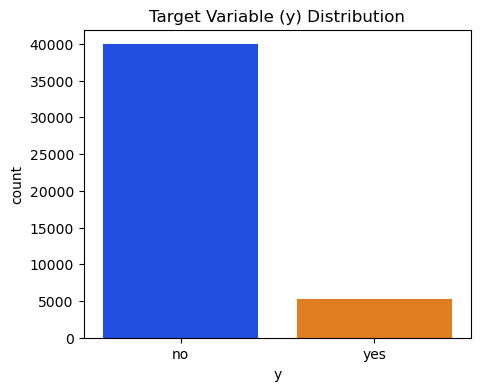

In [17]:
# Visualize imbalance
plt.figure(figsize=(5,4))
sns.countplot(x='y', data=df, palette = 'bright', hue='y')
plt.title("Target Variable (y) Distribution")
plt.show()

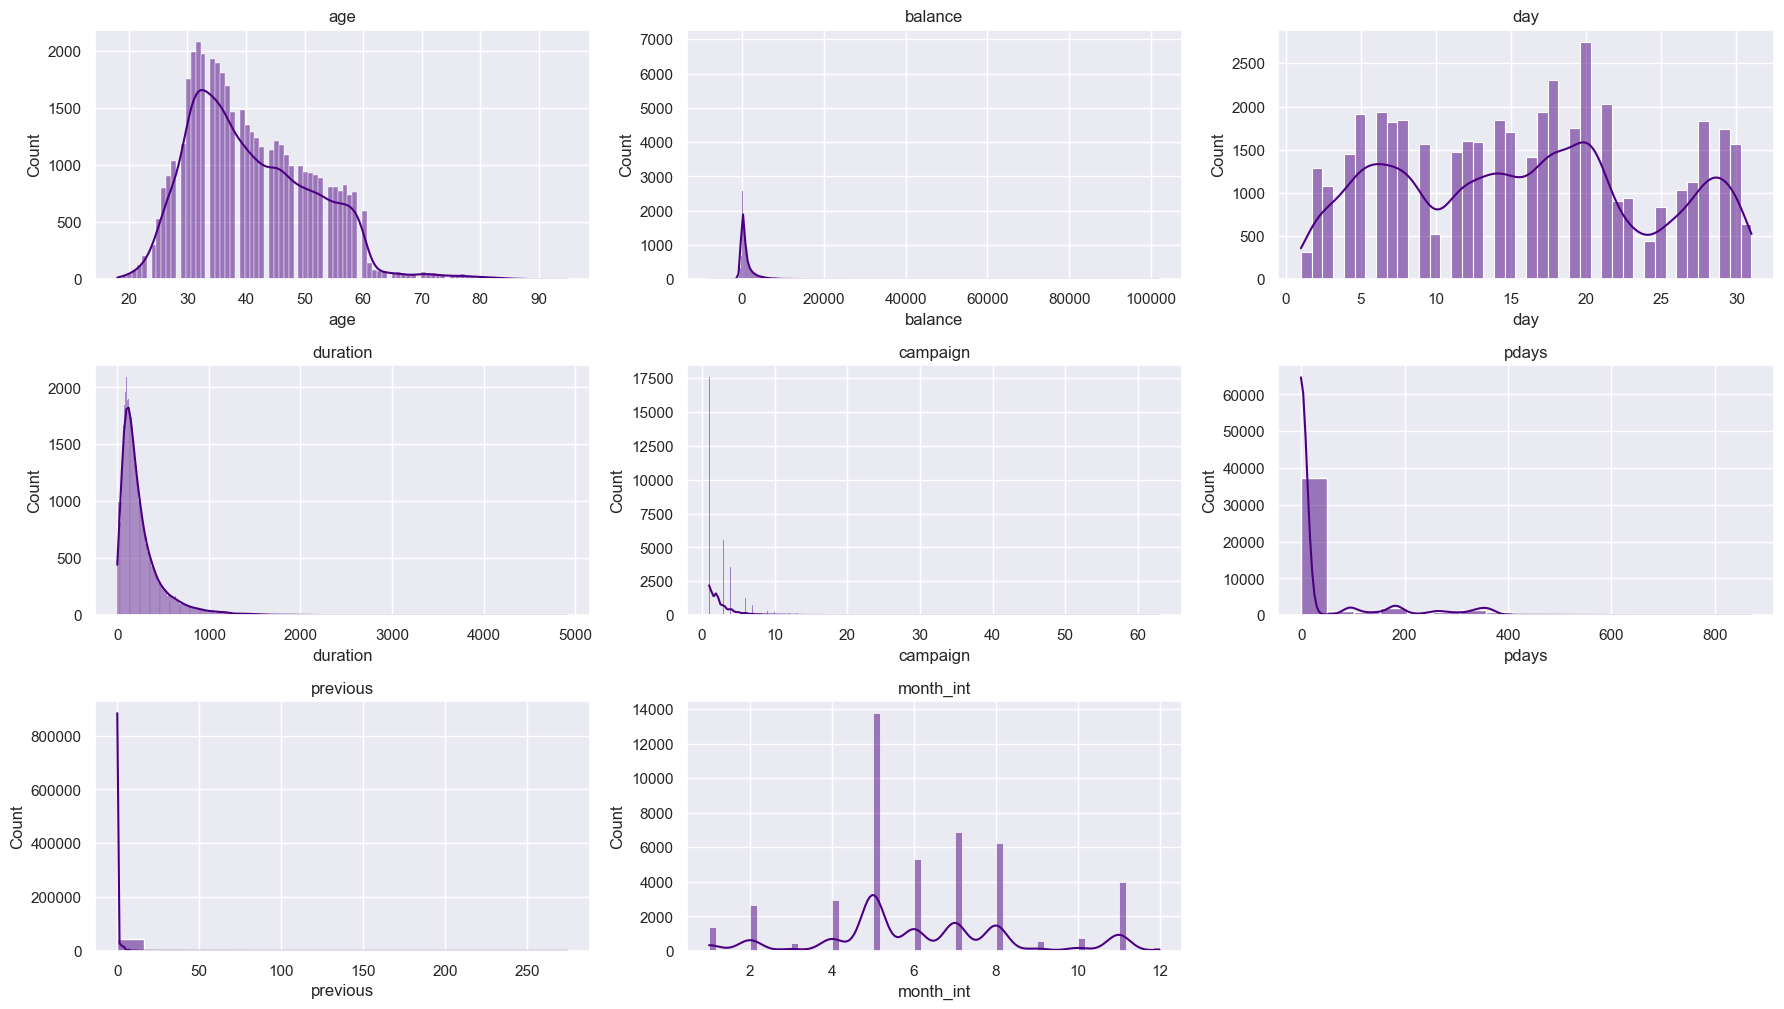

In [18]:
sns.set(rc={'figure.figsize':(9,7)})

# list of all numerical columns from data
num_col = ['age', 'balance', 'day', 'duration','campaign', 'pdays',	'previous', 'month_int']

n=1
plt.figure(figsize=(18,40))
for i in num_col:
  plt.subplot(12,3,n)
  n= n+1
  sns.histplot(df[i],color='indigo', kde=True)
  plt.title(i)
  plt.tight_layout()

In [19]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns.drop('y')
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'poutcome'],
      dtype='object')

## Categorical columns value counts

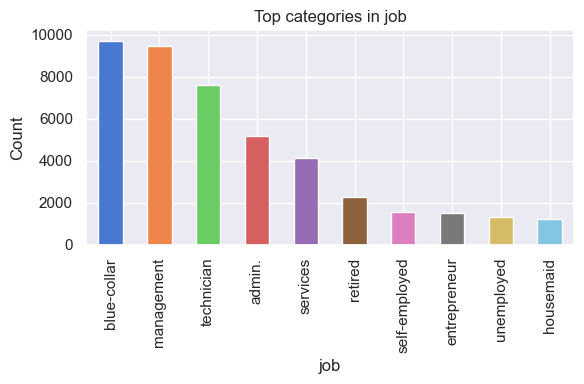

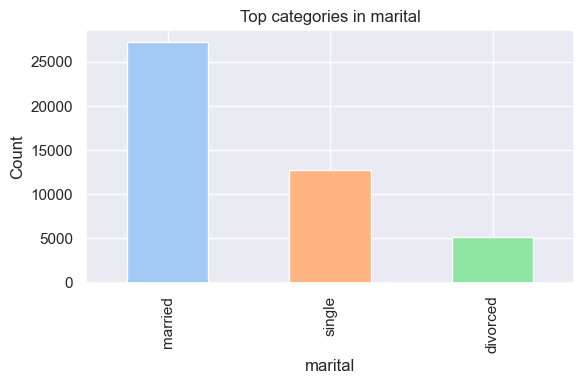

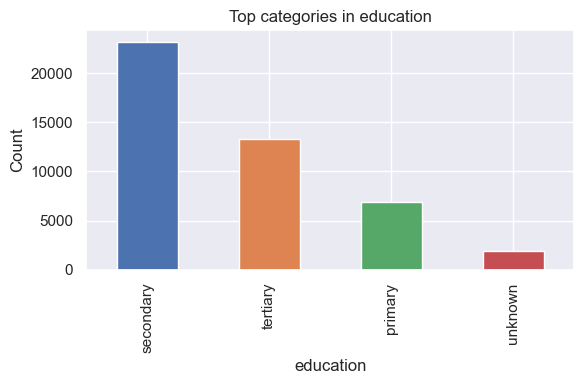

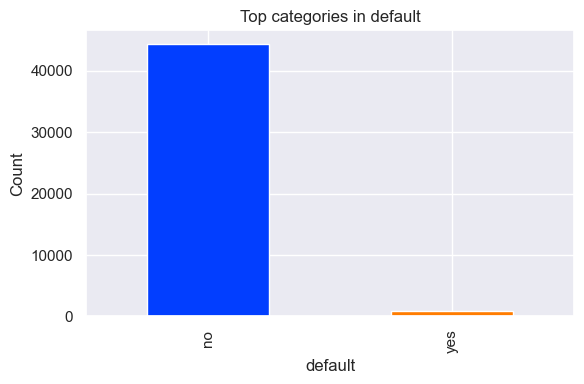

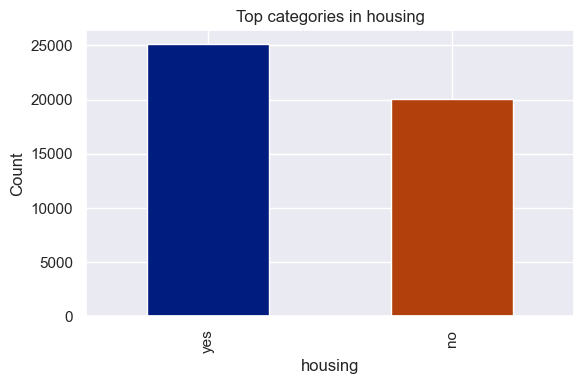

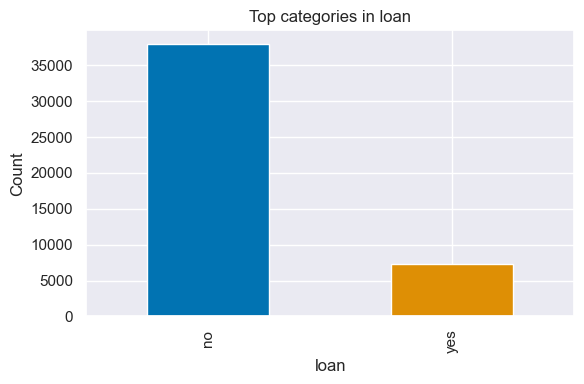

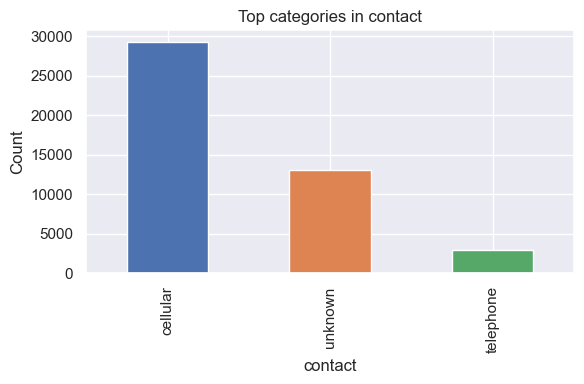

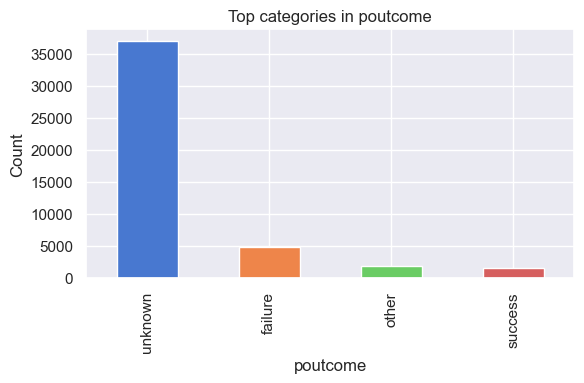

In [20]:
# Categorical columns value counts
palette_colors = ["muted" , "pastel" , "deep" , "bright" , "dark" , "colorblind" , "deep" , "muted" , "pastel"]
i=0
for col in cat_cols:
    plt.figure(figsize=(6,4))
    palette = sns.color_palette(palette_colors[i])
    df[col].value_counts().head(10).plot(kind='bar' , color = palette)
    plt.title(f"Top categories in {col}")
    plt.xlabel(f"{col}")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
    i = i + 1

## Comparing all categorical variables with the target y

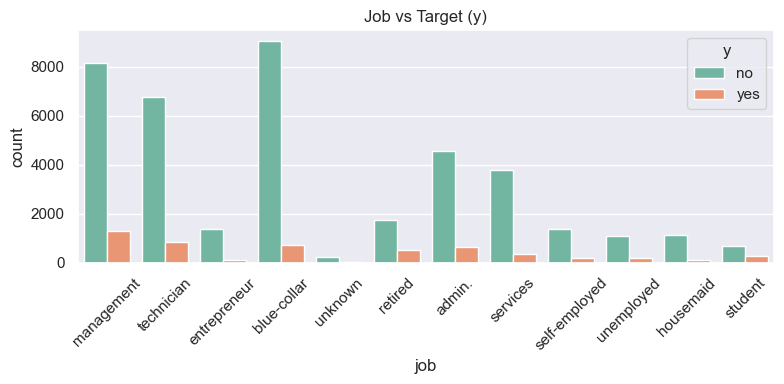

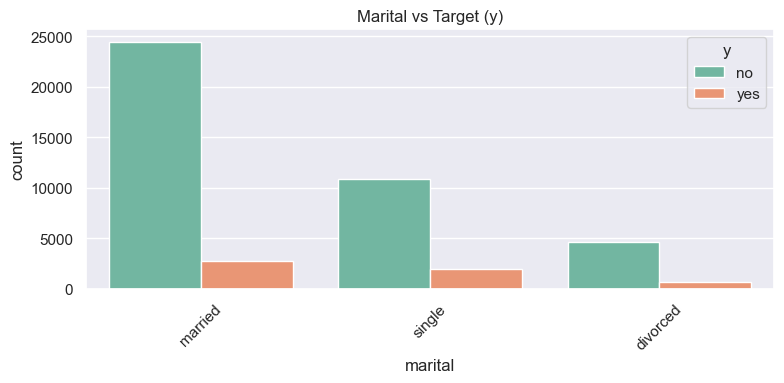

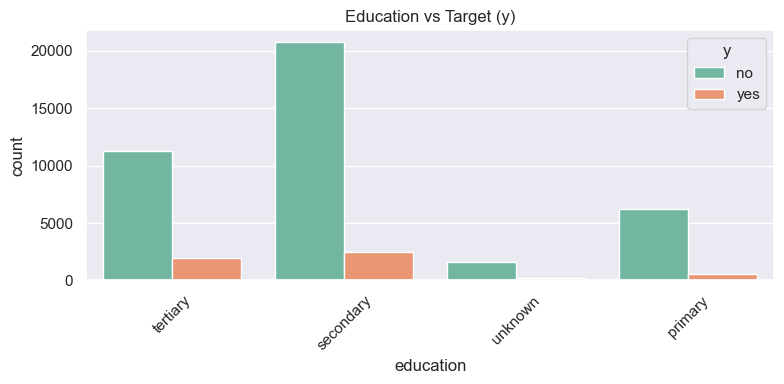

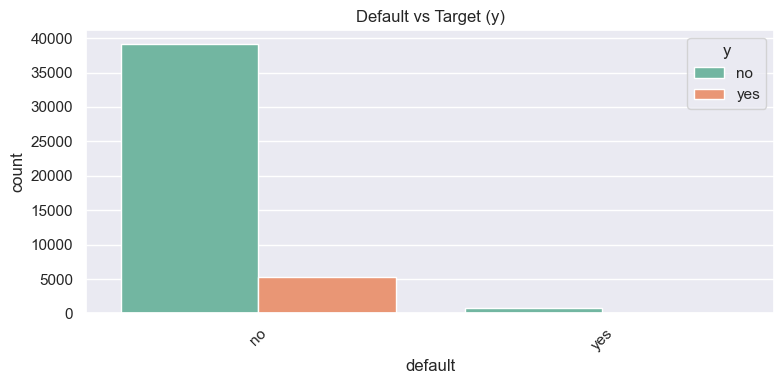

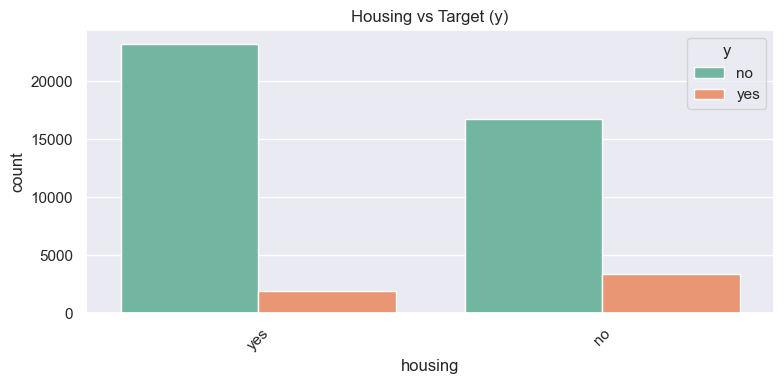

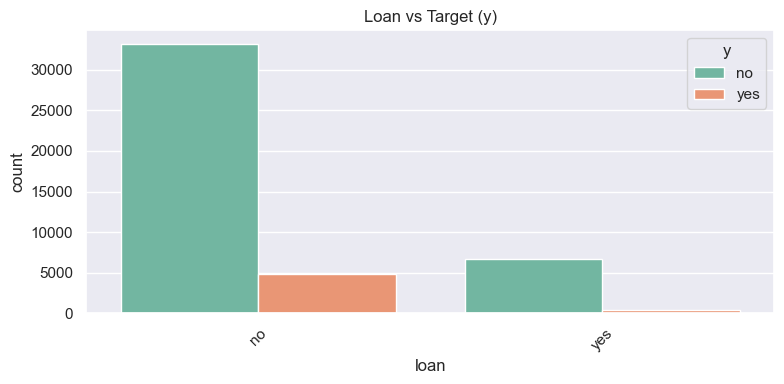

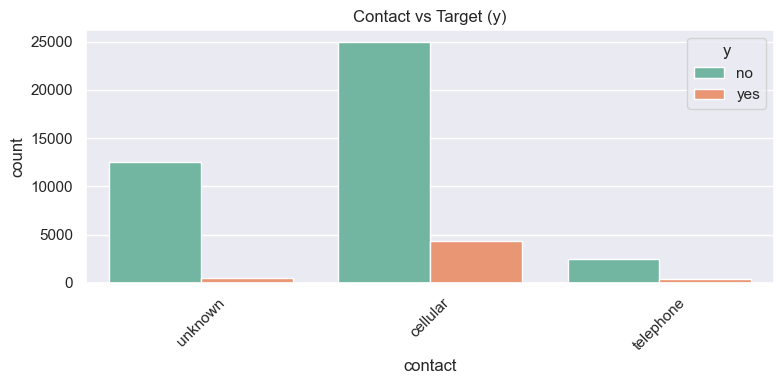

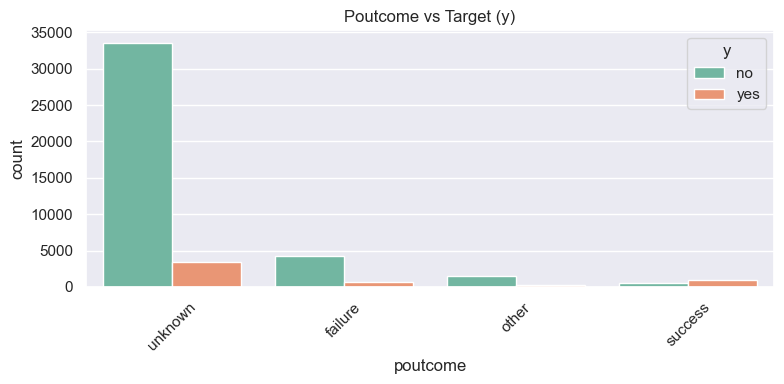

In [21]:
# Comparing all categorical variables with the target y
for col in cat_cols:
    plt.figure(figsize = (8,4))
    sns.countplot(data = df, x = col, hue = 'y', palette = 'Set2')
    plt.title(f"{col.title()} vs Target (y)")
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

# Data Cleaning

## Missing value treatment

In [22]:
## getting the counts of unknown values to capture the information if the missing values are at random or is there
## a pattern in the missing values.

# a dictionay to store data
total_dict={}
un_cat_variables = ['education','job','poutcome','contact']
for col in un_cat_variables:
  total_dict[col] = len(df[df[col]=='unknown']) # storing count of unknown values in dictionary

# converting dictionary to series
print('Total unknown values by features:\n')
pd.Series(total_dict)

Total unknown values by features:



education     1857
job            288
poutcome     36959
contact      13020
dtype: int64

There's no such relation in unknown values, so we need treat them independently.
* unknown values of job feature can be filled with 'other' category.
* education unknown can also be filled as "other".
* poutcome has "unknown" because if a client is not contacted previousluy, its outcome will be "unknown" so we can rename it as "nonexistant" and values as "other" also as non existant.
* for contact feature we can also change this to "other" then it will be easier for further processing.

In [23]:
# replacing "unknown" with "other"
df['job'] = df['job'].replace('unknown', 'other')
df['education'] = df['education'].replace('unknown', 'other')
df['contact'] = df['contact'].replace('unknown', 'other')
# replacing 'unknown' with 'nonexistant' for poutcome
df['poutcome'] = df['poutcome'].replace('unknown', 'nonexistant')

## Outliers treatment

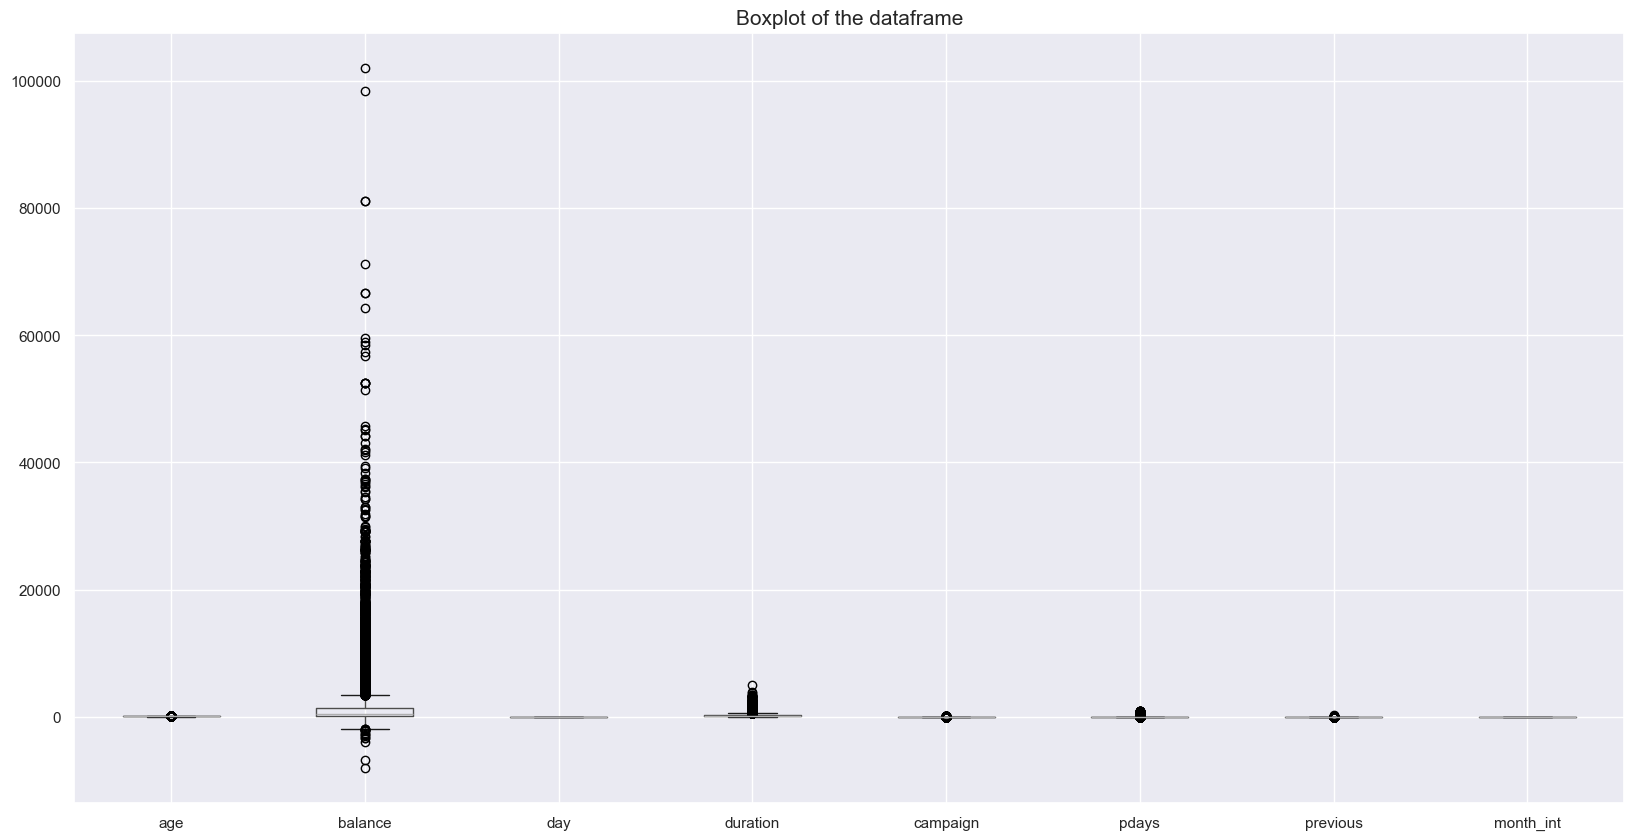

In [24]:
plt.figure(figsize=(20,10))
df.boxplot()
plt.title("Boxplot of the dataframe", fontsize = 15)
print()

We can see that balance feature has some outliers in upper side that may cause some trouble in predictive model.

In [25]:
# getting the Q1 and Q3 quantiles
Q1 = np.percentile(df['balance'], 25, interpolation = 'midpoint')
Q3 = np.percentile(df['balance'], 75, interpolation = 'midpoint')

# calculating interquartile range
IQR = Q3-Q1

# finding the upper limit
upper_lim = Q3+ (1.5*IQR)
upper_lim

np.float64(3462.0)

As per the age distribution and IQR, the upper limit for values in balance is 3500 (approx), but logically there maybe variations in client's balance so we have taken an assumed upper limit of 5000

We will remove records which are above this limit, but to ensure we did not loose our already less proportion of "Yes" in data, we only remove outliers which have not subscribed and keep others as it is.

In [26]:
# storing index of the conditioned rows
drop_index = df[(df['balance']>5000) & (df['y']!='yes')].index

# we have to drop rows on basis of the given condition
df = df.drop(drop_index)

# Preprocessing

## Feature Engineering

Logically, days from 1-30 does not have any ordinal weight so, we have to transform day numbers into week number, so that we can input model the category it belogs to and gave us better results.

We assume an approximation that a month has 4 weeks and 1-7 is week 1, then 7-14 is week 2, then 14-21 is week 3 and morethan 21 is week 4

In [27]:
pd.options.mode.chained_assignment = None

In [28]:
# creting fucntion to convert day to week number of a month.
def day_to_week(day):
  if day <=7:
    return 'week_1'
  elif day <=14:
    return 'week_2'
  elif day <=21:
    return 'week_3'
  else:
    return 'week_4'      

# applying the function to all days
df['week_number'] = df.loc[:,'day'].apply(day_to_week)

In [29]:
# creating function to convert calls times into categories
def previous(call):
  if call == 0:
    return 'not_contacted'

  elif call < 5:
    return 'call_less_thn_5'

  else:
    return 'call_more_thn_5'     

# updating values using the function
df['previous'] = df.loc[:,'previous'].apply(previous)

In [30]:
# creating function to convert month number into quarter.
def quarter_converter(month):
  if month <=3:
    return 'Q_1'

  elif month <=6:
    return 'Q_2'

  elif month <=9:
    return 'Q_3'

  else:
    return 'Q_4'

df.loc[:,'month'] = df['month_int'].apply(quarter_converter)

## Feature encoding

In [31]:
# encoded 0,1,2 for divorced, single and married
df['marital'] = df['marital'].map({'divorced':0, 'single':1, 'married':2})

# encoded education feature as its carries an ordinal weight
df['education'] = df['education'].map({'other':0, 'primary':1, 'secondary':2, 'tertiary':3})

# encoding yes and no of housing and loan
df['housing'] = df['housing'].map({'no':0, 'yes':1})
df['loan'] = df['loan'].map({'no':0, 'yes':1})

# Encoding Target variable
df['y'] = df['y'].map({'no':0, 'yes':1})

# Dropping unimportant feature, as we created alternative 
df = df.drop(['default', 'month_int', 'pdays'], axis=1)

We have to drop default feature because from our EDA, this feature has 90% values as 'no' and it does not impact our subscription rate(target variable)

In [32]:
df.head()

,age,job,marital,education,balance,housing,loan,contact,day,duration,campaign,previous,poutcome,y,week_number,month
0,58,management,2,3,2143,1,0,other,5,261,1,not_contacted,nonexistant,0,week_1,Q_2
1,44,technician,1,2,29,1,0,other,5,151,1,not_contacted,nonexistant,0,week_1,Q_2
2,33,entrepreneur,2,2,2,1,1,other,5,76,1,not_contacted,nonexistant,0,week_1,Q_2
3,47,blue-collar,2,0,1506,1,0,other,5,92,1,not_contacted,nonexistant,0,week_1,Q_2
4,33,other,1,0,1,0,0,other,5,198,1,not_contacted,nonexistant,0,week_1,Q_2


## Correlation and VIF calculation

<Axes: >

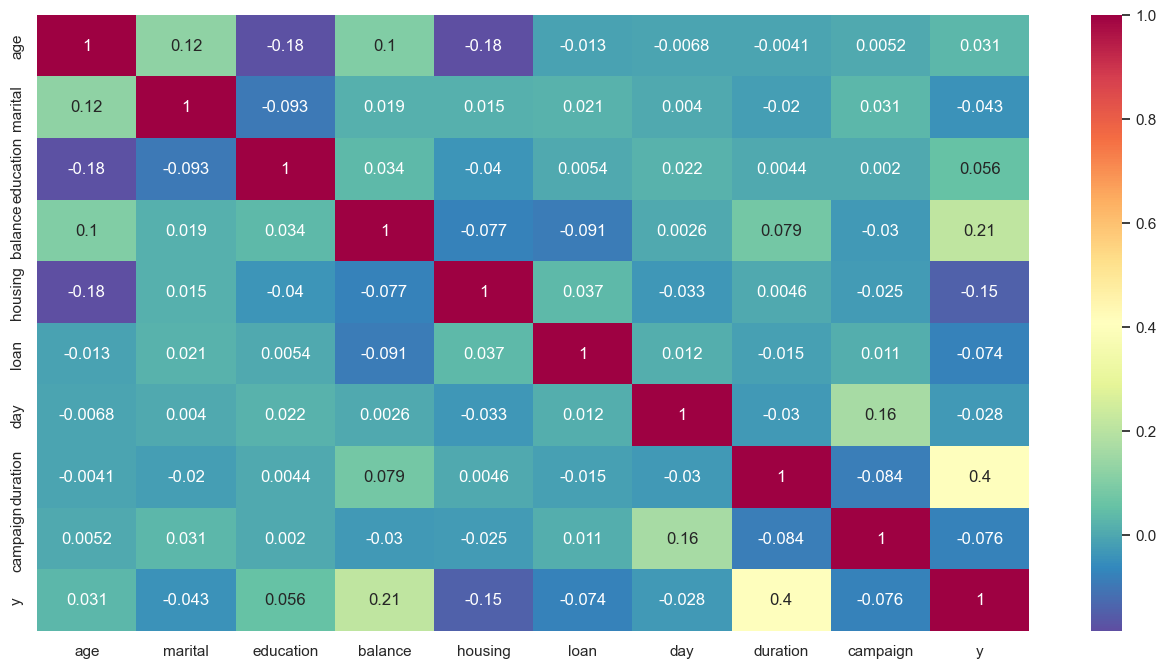

In [33]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation
corr = numeric_df.corr()

# Plot heatmap
fig = plt.figure(figsize=(16,8))
ax = fig.add_subplot(111)
sns.heatmap(corr,annot=True, cmap='Spectral_r')

Not showing any special correlation with our target feature, but as the data says duration is quite related with target and we only use this as benchmark model and cannot use this in the predictive model.

## Checking VIF

In [34]:
# Importing necessary library
from statsmodels.stats.outliers_influence import variance_inflation_factor

# creating function for VIF calculation.
def cal_VIF(F): 
   VIF = pd.DataFrame()
   VIF["variables"] = F.columns
   VIF["VIF"] = [variance_inflation_factor(F.values, i) for i in range(F.shape[1])]
   return(VIF)

In [35]:
# calculating VIF for all numerical feature, except target variable-"y"
cal_VIF(df[[i for i in df.describe().columns if i !='y']])

,variables,VIF
0,age,8.790835
1,marital,5.216650
2,education,5.707764
3,balance,1.336584
4,housing,2.114747
5,loan,1.205323
6,day,4.332255
7,duration,1.970221
8,campaign,1.845800


The default threshold of VIF is 5 but it also depends case to case, we have to remove age then go further with the remaining features.

In [36]:
df1 = df.copy()

In [37]:
df1 = df1.drop('age' , axis = 1)

In [38]:
# calculating VIF for all numerical feature, except target variable-"y"
cal_VIF(df1[[i for i in df1.describe().columns if i !='y']])

,variables,VIF
0,marital,4.112274
1,education,4.928768
2,balance,1.311303
3,housing,2.105898
4,loan,1.201484
5,day,4.002791
6,duration,1.914755
7,campaign,1.826819


now we have all VIF < 5 now we can procceed. We will test the models result for both with the variable age and without.

## One Hot Encoding

In [39]:
# getting dummies using get dummies method of pandas
df = pd.get_dummies(df, drop_first=True)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
df

,age,marital,education,balance,housing,loan,day,duration,campaign,y,...,previous_not_contacted,poutcome_nonexistant,poutcome_other,poutcome_success,week_number_week_2,week_number_week_3,week_number_week_4,month_Q_2,month_Q_3,month_Q_4
0,58,2,3,2143,1,0,5,261,1,0,...,1,1,0,0,0,0,0,1,0,0
1,44,1,2,29,1,0,5,151,1,0,...,1,1,0,0,0,0,0,1,0,0
2,33,2,2,2,1,1,5,76,1,0,...,1,1,0,0,0,0,0,1,0,0
3,47,2,0,1506,1,0,5,92,1,0,...,1,1,0,0,0,0,0,1,0,0
4,33,1,0,1,0,0,5,198,1,0,...,1,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,2,3,825,0,0,17,977,3,1,...,1,1,0,0,0,1,0,0,0,1
45207,71,0,1,1729,0,0,17,456,2,1,...,1,1,0,0,0,1,0,0,0,1
45208,72,2,2,5715,0,0,17,1127,5,1,...,0,0,0,1,0,1,0,0,0,1
45209,57,2,2,668,0,0,17,508,4,0,...,1,1,0,0,0,1,0,0,0,1


In [40]:
df1 = pd.get_dummies(df1, drop_first=True)
bool_cols = df1.select_dtypes(include=['bool']).columns
df1[bool_cols] = df1[bool_cols].astype(int)
df1

,marital,education,balance,housing,loan,day,duration,campaign,y,job_blue-collar,...,previous_not_contacted,poutcome_nonexistant,poutcome_other,poutcome_success,week_number_week_2,week_number_week_3,week_number_week_4,month_Q_2,month_Q_3,month_Q_4
0,2,3,2143,1,0,5,261,1,0,0,...,1,1,0,0,0,0,0,1,0,0
1,1,2,29,1,0,5,151,1,0,0,...,1,1,0,0,0,0,0,1,0,0
2,2,2,2,1,1,5,76,1,0,0,...,1,1,0,0,0,0,0,1,0,0
3,2,0,1506,1,0,5,92,1,0,1,...,1,1,0,0,0,0,0,1,0,0
4,1,0,1,0,0,5,198,1,0,0,...,1,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,2,3,825,0,0,17,977,3,1,0,...,1,1,0,0,0,1,0,0,0,1
45207,0,1,1729,0,0,17,456,2,1,0,...,1,1,0,0,0,1,0,0,0,1
45208,2,2,5715,0,0,17,1127,5,1,0,...,0,0,0,1,0,1,0,0,0,1
45209,2,2,668,0,0,17,508,4,0,1,...,1,1,0,0,0,1,0,0,0,1


Our categories converted to columns and are encoded with 0 or 1 values, moreover we have dropped first categories from all one hot encodings to remove multicollinearity.

## Feature Selection/Feature Importance

In [41]:
# seperating dependent and independent variable
x = df.drop('y', axis=1)
y = df['y']

x1 = df1.drop('y', axis=1)
y1 = df1['y']

In [42]:
from sklearn.feature_selection import SelectKBest, f_classif

# selecting k best features using annova test
bestfeature = SelectKBest(f_classif, k=31)
fit = bestfeature.fit(x,y)

# converting the scores into dataframe for better presentation
df_score = pd.DataFrame(fit.scores_)
df_col = pd.DataFrame(x.columns)
feature_scores = pd.concat([df_col, df_score], axis=1)
feature_scores.columns = ['feature', 'score']

# lets see the important features 
feature_scores.sort_values(by='score', ascending=False)

,feature,score
7,duration,8291.663506
26,poutcome_success,4580.354414
3,balance,1997.666250
23,previous_not_contacted,1310.426962
24,poutcome_nonexistant,1307.119687
20,contact_other,1071.147849
4,housing,935.461644
22,previous_call_more_thn_5,324.552889
14,job_retired,296.589144
17,job_student,268.245387


In [43]:
from sklearn.feature_selection import SelectKBest, f_classif

# selecting k best features using annova test
bestfeature1 = SelectKBest(f_classif, k=31)
fit1 = bestfeature1.fit(x1,y1)

# converting the scores into dataframe for better presentation
df1_score = pd.DataFrame(fit1.scores_)
df1_col = pd.DataFrame(x1.columns)
feature_scores1 = pd.concat([df1_col, df1_score], axis=1)
feature_scores1.columns = ['feature', 'score']

# lets see the important features 
feature_scores1.sort_values(by='score', ascending=False)

,feature,score
6,duration,8291.663506
25,poutcome_success,4580.354414
2,balance,1997.666250
22,previous_not_contacted,1310.426962
23,poutcome_nonexistant,1307.119687
19,contact_other,1071.147849
3,housing,935.461644
21,previous_call_more_thn_5,324.552889
13,job_retired,296.589144
16,job_student,268.245387


* We noticed here and already stated earlier that duration is directly impacting subscription rate, so here also its came out as the most important feature

* Drop all features less than 5 ( <5 )

* week_4 , job_self_employed , job_other , job_technician are the least important, so decided to remove these features.

* week_number_week_3 , job_retired , job_management , month_Q_4 , job_technician

* Since 'day' also has converted to weeks numbers and is less important so we can remove it.

In [44]:
df = df.drop(['job_technician' , 'month_Q_3' , 'week_number_week_4' , 'job_self-employed' , 'job_other' , 'day'], axis=1)

# seperating dependent and independent variable
x = df.drop('y', axis=1)
y = df['y']

df1 = df1.drop(['job_technician' , 'month_Q_3' , 'week_number_week_4' , 'job_self-employed' , 'job_other' , 'day'], axis=1)

# seperating dependent and independent variable
x1 = df1.drop('y', axis=1)
y1 = df1['y']

## Train-Test split data

In [45]:
from sklearn.model_selection import train_test_split
## with the age column
# splitting data with 70% as train and 30% as test data 
x_train_a, x_test_a, y_train_a, y_test_a = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print(x_train_a.shape, x_test_a.shape, '\n')
print(y_train_a.value_counts())
counts = y_train_a.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)

# splitting data with 75% as train and 25% as test data  
x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

print(x_train_b.shape, x_test_b.shape, '\n')
print(y_train_b.value_counts())
counts = y_train_b.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)

# splitting data with 80% as train and 20% as test data  
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(x_train_c.shape, x_test_c.shape, '\n')
print(y_train_c.value_counts())
counts = y_train_c.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)


## Without age column
# splitting data with 70% as train and 30% as test data 
x_train_a_1, x_test_a_1, y_train_a_1, y_test_a_1 = train_test_split(x1, y1, test_size=0.3, random_state=42, stratify=y)

print(x_train_a_1.shape, x_test_a_1.shape, '\n')
print(y_train_a_1.value_counts())
counts = y_train_a_1.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)

# splitting data with 75% as train and 25% as test data  
x_train_b_1, x_test_b_1, y_train_b_1, y_test_b_1 = train_test_split(x1, y1, test_size=0.25, random_state=42, stratify=y)

print(x_train_b_1.shape, x_test_b_1.shape, '\n')
print(y_train_b_1.value_counts())
counts = y_train_b_1.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)

# splitting data with 80% as train and 20% as test data  
x_train_c_1, x_test_c_1, y_train_c_1, y_test_c_1 = train_test_split(x1, y1, test_size=0.2, random_state=42, stratify=y)

print(x_train_c_1.shape, x_test_c_1.shape, '\n')
print(y_train_c_1.value_counts())
counts = y_train_c_1.value_counts()
ratio = counts[0] / counts[1]  # majority / minority
print("Class ratio (majority : minority) =", ratio)

(29964, 27) (12843, 27) 

y
0    26262
1     3702
Name: count, dtype: int64
Class ratio (majority : minority) = 7.094003241491086
(32105, 27) (10702, 27) 

y
0    28138
1     3967
Name: count, dtype: int64
Class ratio (majority : minority) = 7.0930173934963445
(34245, 27) (8562, 27) 

y
0    30014
1     4231
Name: count, dtype: int64
Class ratio (majority : minority) = 7.093831245568423
(29964, 26) (12843, 26) 

y
0    26262
1     3702
Name: count, dtype: int64
Class ratio (majority : minority) = 7.094003241491086
(32105, 26) (10702, 26) 

y
0    28138
1     3967
Name: count, dtype: int64
Class ratio (majority : minority) = 7.0930173934963445
(34245, 26) (8562, 26) 

y
0    30014
1     4231
Name: count, dtype: int64
Class ratio (majority : minority) = 7.093831245568423


* ratio 8:1 
* Many classifiers (RandomForest, Logistic Regression, XGBoost) tend to favor the majority class.

Without correcting the imbalance:

* The model might predict all zeros (majority class) and achieve high accuracy, but fail to detect the minority class.

* Metrics like recall, F1-score, or ROC-AUC for the minority class will be poor.

### Now there are two ways to proceed further:

* Handling balance using Oversampling - SMOTEtomek
* Using Undersampling- Nearmiss

# Handling Imbalance classes (Oversampling)

* SMOTE → Synthetic Minority Oversampling Technique (creates synthetic minority samples).
* Tomek Links → Undersampling method that removes overlapping samples from the majority class.

In [46]:
## With age
# using combination of smote and tomek-links to over and undersample data 
from imblearn.combine import SMOTETomek

# defining smotetomek object
smo_tek_a = SMOTETomek(random_state=42)
x_train_smotek_a, y_train_smotek_a = smo_tek_a.fit_resample(x_train_a, y_train_a) #resampling training data and balance of class

print(x_train_smotek_a.shape, '\n')
print(y_train_smotek_a.value_counts())


smo_tek_b = SMOTETomek(random_state=42)
x_train_smotek_b, y_train_smotek_b = smo_tek_b.fit_resample(x_train_b, y_train_b) 

print(x_train_smotek_b.shape, '\n')
print(y_train_smotek_b.value_counts())


smo_tek_c = SMOTETomek(random_state=42)
x_train_smotek_c, y_train_smotek_c = smo_tek_c.fit_resample(x_train_c, y_train_c) 

print(x_train_smotek_c.shape, '\n')
print(y_train_smotek_c.value_counts())



## Without age
# defining smotetomek object
smo_tek_a_1 = SMOTETomek(random_state=42)
x_train_smotek_a_1, y_train_smotek_a_1 = smo_tek_a_1.fit_resample(x_train_a_1, y_train_a_1) #resampling training data and balance of class

print(x_train_smotek_a_1.shape, '\n')
print(y_train_smotek_a_1.value_counts())


smo_tek_b_1 = SMOTETomek(random_state=42)
x_train_smotek_b_1, y_train_smotek_b_1 = smo_tek_b_1.fit_resample(x_train_b_1, y_train_b_1) 

print(x_train_smotek_b_1.shape, '\n')
print(y_train_smotek_b_1.value_counts())


smo_tek_c_1 = SMOTETomek(random_state=42)
x_train_smotek_c_1, y_train_smotek_c_1 = smo_tek_c_1.fit_resample(x_train_c_1, y_train_c_1) 

print(x_train_smotek_c_1.shape, '\n')
print(y_train_smotek_c_1.value_counts())

(50538, 27) 

y
0    25269
1    25269
Name: count, dtype: int64
(54220, 27) 

y
0    27110
1    27110
Name: count, dtype: int64
(57850, 27) 

y
0    28925
1    28925
Name: count, dtype: int64
(49648, 26) 

y
0    24824
1    24824
Name: count, dtype: int64
(53378, 26) 

y
0    26689
1    26689
Name: count, dtype: int64
(56900, 26) 

y
0    28450
1    28450
Name: count, dtype: int64


We have used SMOTE (Synthetic Minority Oversampling Technique) and Tommek links combination to oversample minority as well as undersample majority class to create a balance in classes.

Now that we have handled the class balance, we can go further in process to scale the features.

## Feature Scaling

In [47]:
from sklearn.preprocessing import StandardScaler
## With age
# using the standard scaler from sklearn to standardize the features
scaler_a = StandardScaler()
x_train_sm_a = scaler_a.fit_transform(x_train_smotek_a) 
x_test_sm_a = scaler_a.transform(x_test_a)
y_train_sm_a = y_train_smotek_a 
y_test_sm_a = y_test_a

scaler_b = StandardScaler()
x_train_sm_b = scaler_b.fit_transform(x_train_smotek_b) 
x_test_sm_b = scaler_b.transform(x_test_b)
y_train_sm_b = y_train_smotek_b 
y_test_sm_b = y_test_b

scaler_c = StandardScaler()
x_train_sm_c = scaler_c.fit_transform(x_train_smotek_c) 
x_test_sm_c = scaler_c.transform(x_test_c)
y_train_sm_c = y_train_smotek_c 
y_test_sm_c = y_test_c


In [48]:
## Wihtout age
# using the standard scaler from sklearn to standardize the features
scaler_a_1 = StandardScaler()
x_train_sm_a_1 = scaler_a_1.fit_transform(x_train_smotek_a_1) 
x_test_sm_a_1 = scaler_a_1.transform(x_test_a_1)
y_train_sm_a_1 = y_train_smotek_a_1 
y_test_sm_a_1 = y_test_a_1

scaler_b_1 = StandardScaler()
x_train_sm_b_1 = scaler_b_1.fit_transform(x_train_smotek_b_1) 
x_test_sm_b_1 = scaler_b_1.transform(x_test_b_1)
y_train_sm_b_1 = y_train_smotek_b_1 
y_test_sm_b_1 = y_test_b_1

scaler_c_1 = StandardScaler()
x_train_sm_c_1 = scaler_c_1.fit_transform(x_train_smotek_c_1) 
x_test_sm_c_1 = scaler_c_1.transform(x_test_c_1)
y_train_sm_c_1 = y_train_smotek_c_1 
y_test_sm_c_1 = y_test_c_1

# Model Building

In [52]:
# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (confusion_matrix , classification_report , roc_curve , auc)

In [53]:
def evaluate_models(X_train, X_test, y_train, y_test, title="Dataset"):
    
    print(f"\n==================== {title} ====================\n")
    
    models = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "SVM": SVC(probability=True),
        "Random Forest": RandomForestClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            tree_method="hist",
            use_label_encoder=False
        )
    }
    
    results = {}

    # Training
    for name, model in models.items():
        print(f"\n- Model: {name}")
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        # Store info
        results[name] = {
            "model": model,
            "pred": y_pred,
            "prob": y_prob,
            "cm": confusion_matrix(y_test, y_pred)
        }
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

    # Confusion Matrices
    plt.figure(figsize=(8, 5))
    plt.suptitle(f"Confusion Matrices – {title}", fontsize=18)
    
    for i, (name, res) in enumerate(results.items(), 1):
        plt.subplot(2, 3, i)
        sns.heatmap(res["cm"], annot=True, fmt="d", cmap="Blues")
        plt.title(name)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

    # ROC Curves
    plt.figure(figsize=(10, 7))
    
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res["prob"])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves – {title}", fontsize=16)
    plt.legend()
    plt.show()

    return results


==================== With Age – Dataset A ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     11256
           1       0.44      0.56      0.50      1587

    accuracy                           0.86     12843
   macro avg       0.69      0.73      0.71     12843
weighted avg       0.88      0.86      0.87     12843


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     11256
           1       0.49      0.58      0.53      1587

    accuracy                           0.87     12843
   macro avg       0.71      0.75      0.73     12843
weighted avg       0.88      0.87      0.88     12843


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     11256
           1       0.53   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:06:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     11256
           1       0.50      0.59      0.54      1587

    accuracy                           0.88     12843
   macro avg       0.72      0.76      0.74     12843
weighted avg       0.89      0.88      0.88     12843



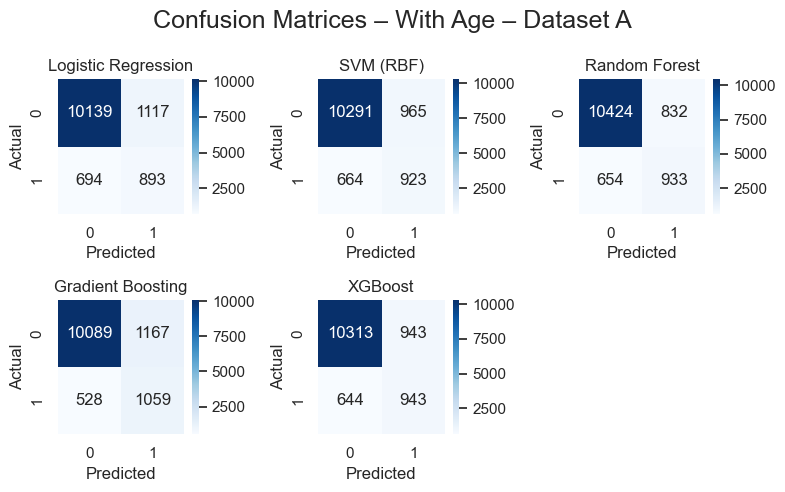

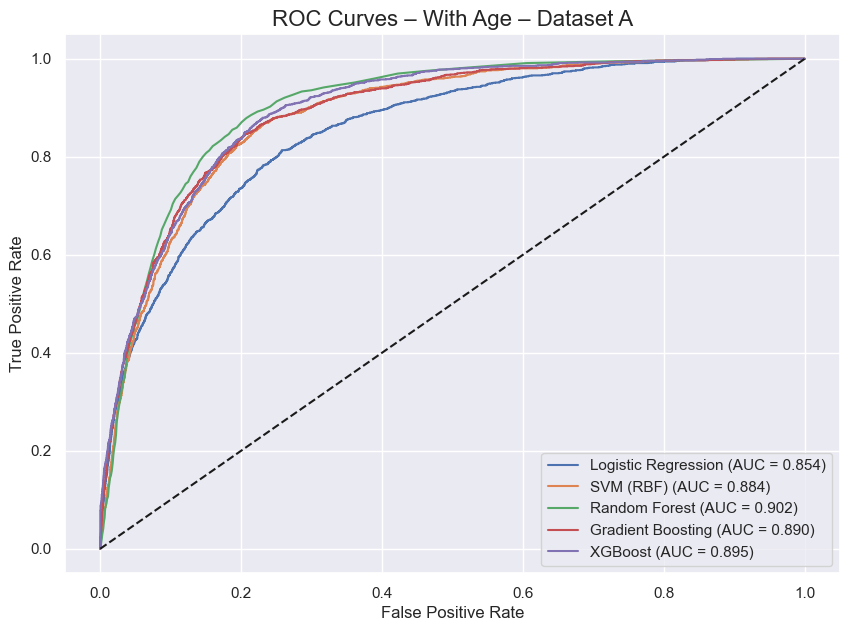


==================== With Age – Dataset B ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      9380
           1       0.45      0.57      0.50      1322

    accuracy                           0.86     10702
   macro avg       0.69      0.73      0.71     10702
weighted avg       0.88      0.86      0.87     10702


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      9380
           1       0.49      0.59      0.54      1322

    accuracy                           0.87     10702
   macro avg       0.72      0.75      0.73     10702
weighted avg       0.89      0.87      0.88     10702


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      9380
           1       0.53   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:13:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      9380
           1       0.52      0.61      0.56      1322

    accuracy                           0.88     10702
   macro avg       0.73      0.77      0.75     10702
weighted avg       0.89      0.88      0.89     10702



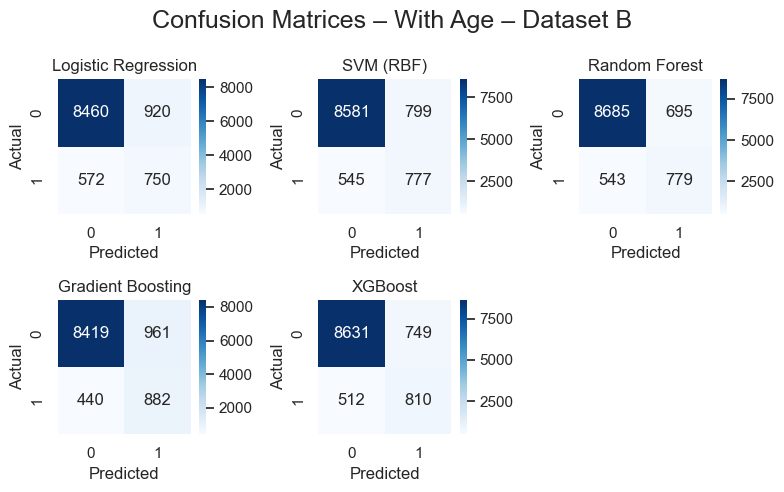

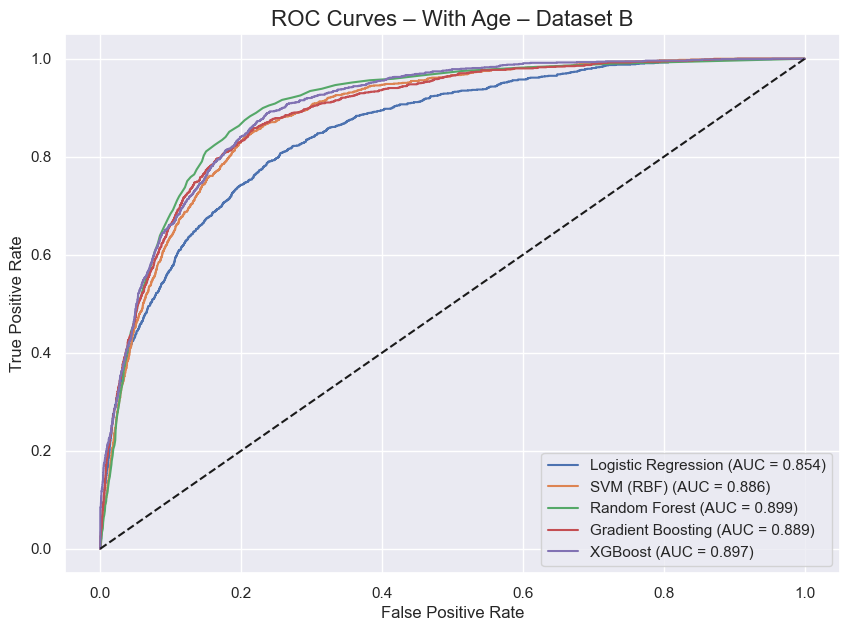


==================== With Age – Dataset C ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7504
           1       0.45      0.56      0.50      1058

    accuracy                           0.86      8562
   macro avg       0.69      0.73      0.71      8562
weighted avg       0.88      0.86      0.87      8562


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7504
           1       0.49      0.59      0.53      1058

    accuracy                           0.87      8562
   macro avg       0.71      0.75      0.73      8562
weighted avg       0.88      0.87      0.88      8562


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7504
           1       0.54   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:20:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7504
           1       0.51      0.60      0.55      1058

    accuracy                           0.88      8562
   macro avg       0.73      0.76      0.74      8562
weighted avg       0.89      0.88      0.88      8562



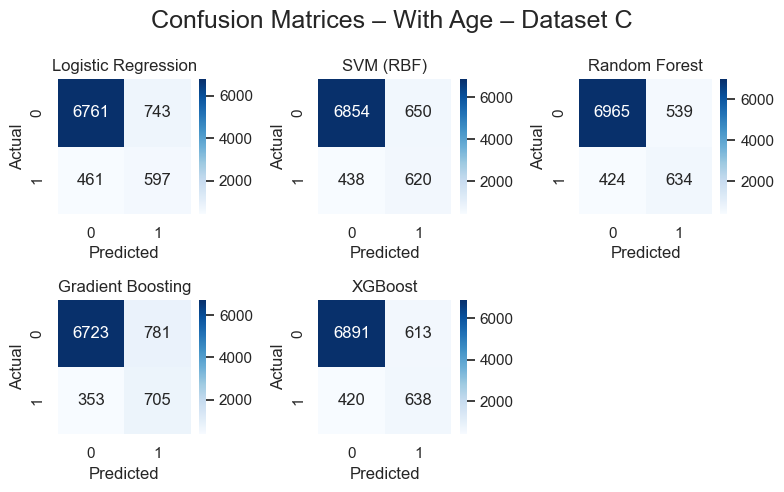

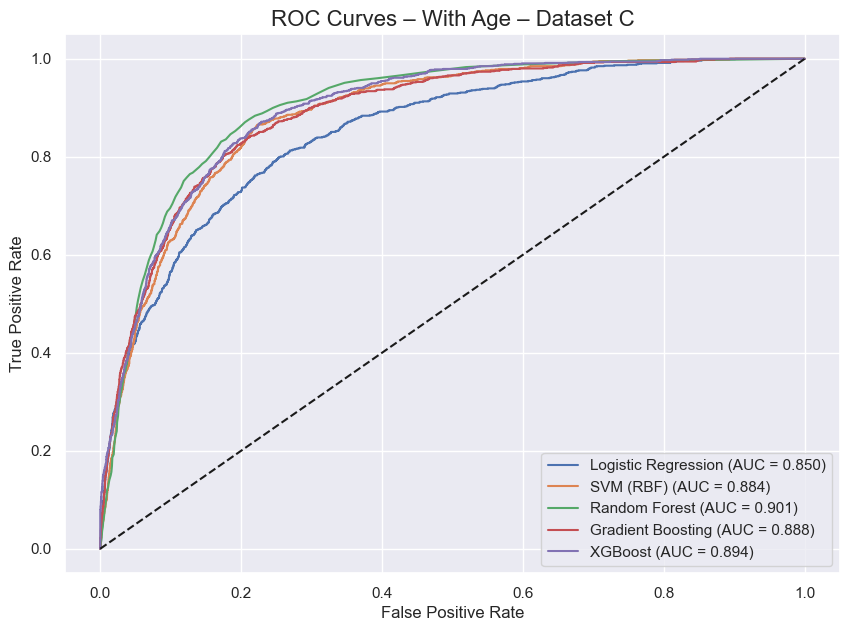

In [54]:
# Testing
results_A_with_age = evaluate_models(
    x_train_sm_a, x_test_sm_a, y_train_sm_a, y_test_sm_a,
    title="With Age – Dataset A"
)

results_B_with_age = evaluate_models(
    x_train_sm_b, x_test_sm_b, y_train_sm_b, y_test_sm_b,
    title="With Age – Dataset B"
)

results_C_with_age = evaluate_models(
    x_train_sm_c, x_test_sm_c, y_train_sm_c, y_test_sm_c,
    title="With Age – Dataset C"
)


==================== Without Age – Dataset A ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     11256
           1       0.45      0.56      0.50      1587

    accuracy                           0.86     12843
   macro avg       0.69      0.73      0.71     12843
weighted avg       0.88      0.86      0.87     12843


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93     11256
           1       0.48      0.57      0.53      1587

    accuracy                           0.87     12843
   macro avg       0.71      0.74      0.73     12843
weighted avg       0.88      0.87      0.88     12843


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93     11256
           1       0.52

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:34:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     11256
           1       0.50      0.60      0.54      1587

    accuracy                           0.88     12843
   macro avg       0.72      0.76      0.74     12843
weighted avg       0.89      0.88      0.88     12843



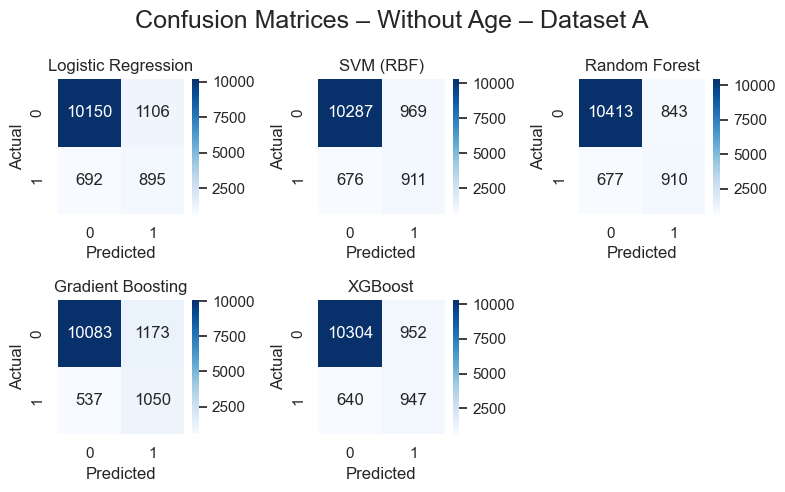

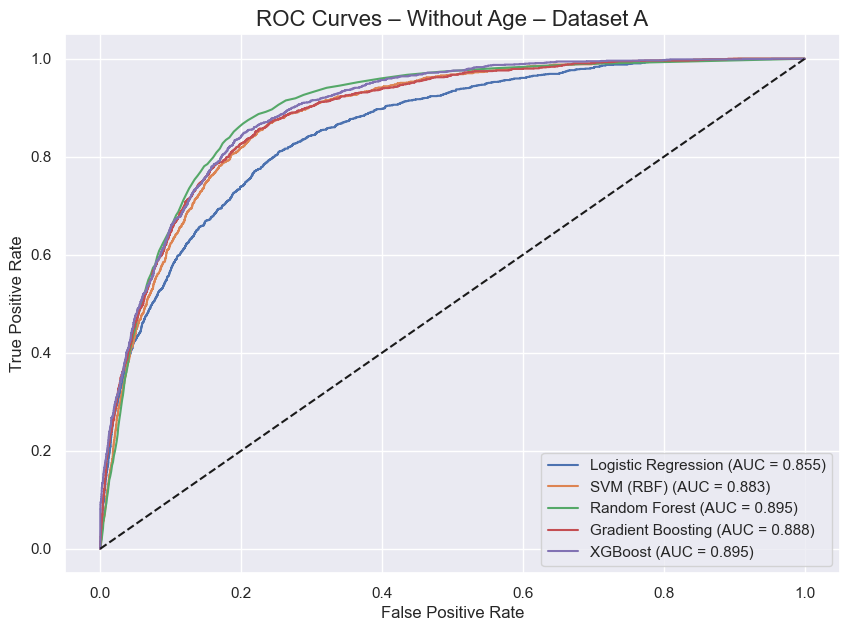


==================== Without Age – Dataset B ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      9380
           1       0.45      0.56      0.50      1322

    accuracy                           0.86     10702
   macro avg       0.69      0.73      0.71     10702
weighted avg       0.88      0.86      0.87     10702


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      9380
           1       0.49      0.58      0.53      1322

    accuracy                           0.87     10702
   macro avg       0.71      0.75      0.73     10702
weighted avg       0.88      0.87      0.88     10702


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      9380
           1       0.53

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:40:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      9380
           1       0.50      0.60      0.54      1322

    accuracy                           0.88     10702
   macro avg       0.72      0.76      0.74     10702
weighted avg       0.89      0.88      0.88     10702



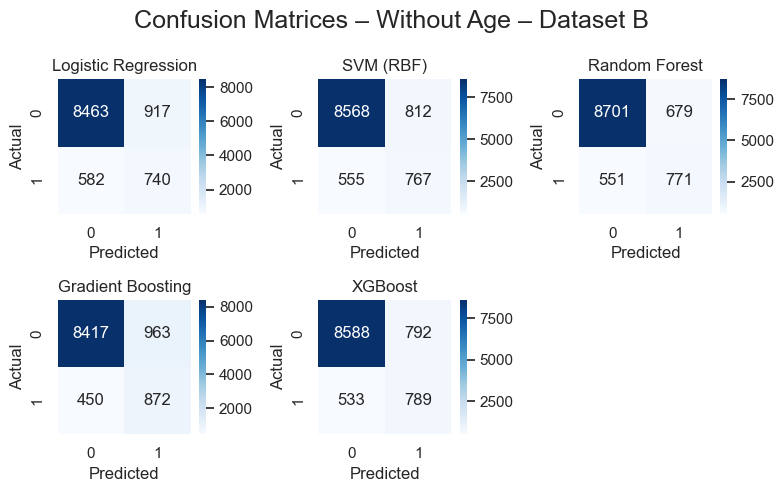

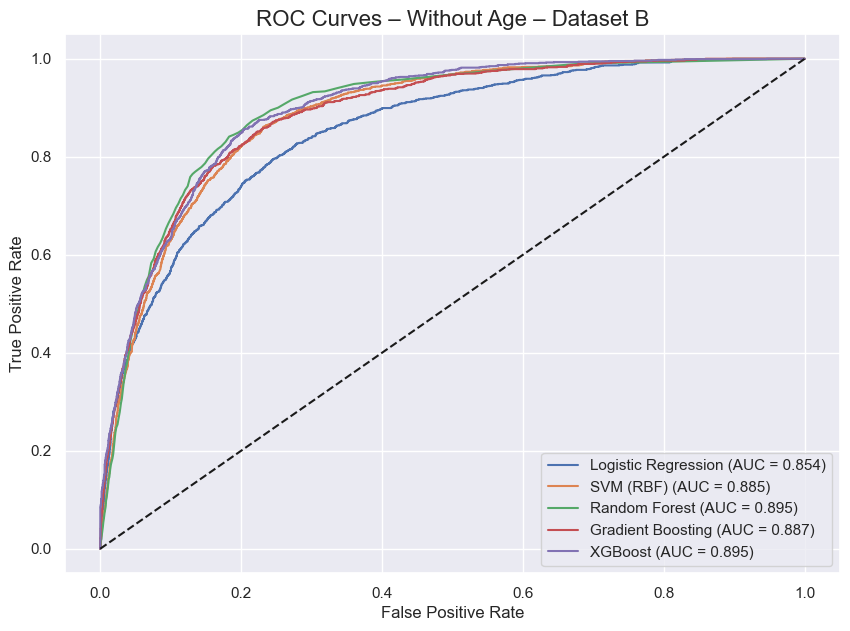


==================== Without Age – Dataset C ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7504
           1       0.45      0.56      0.50      1058

    accuracy                           0.86      8562
   macro avg       0.69      0.73      0.71      8562
weighted avg       0.88      0.86      0.87      8562


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7504
           1       0.48      0.57      0.52      1058

    accuracy                           0.87      8562
   macro avg       0.71      0.74      0.72      8562
weighted avg       0.88      0.87      0.88      8562


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      7504
           1       0.52

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:46:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7504
           1       0.50      0.60      0.55      1058

    accuracy                           0.88      8562
   macro avg       0.72      0.76      0.74      8562
weighted avg       0.89      0.88      0.88      8562



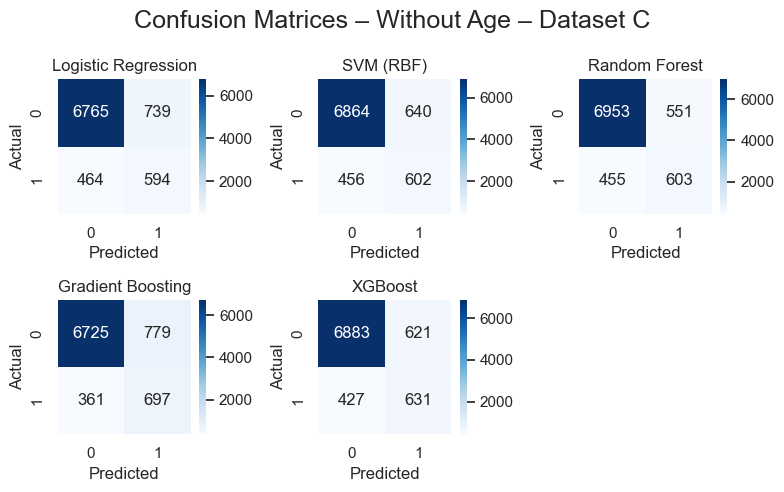

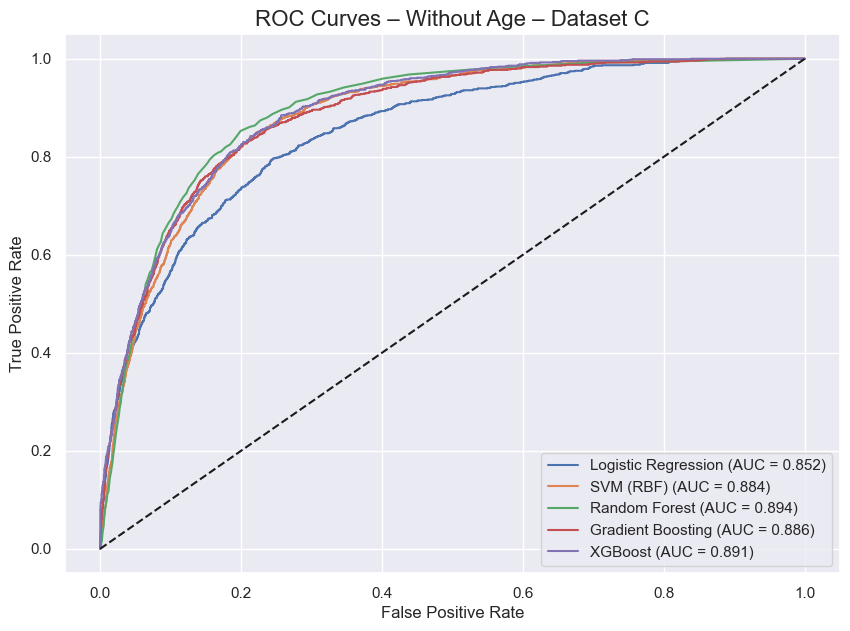

In [57]:
#Testing
results_A_without_age = evaluate_models(
    x_train_sm_a_1, x_test_sm_a_1, y_train_sm_a_1, y_test_sm_a_1,
    title="Without Age – Dataset A"
)

results_B_without_age = evaluate_models(
    x_train_sm_b_1, x_test_sm_b_1, y_train_sm_b_1, y_test_sm_b_1,
    title="Without Age – Dataset B"
)

results_C_without_age = evaluate_models(
    x_train_sm_c_1, x_test_sm_c_1, y_train_sm_c_1, y_test_sm_c_1,
    title="Without Age – Dataset C"
)

Now we have to go for our 2nd option to use the undersampling technique as it seems to be more compatible with this data because this is large data and we may use undersampling.

## Handling Imbalance classes (Undersampling)

In [56]:
# using Nearmiss which reduce higherclass data using the average distances
from imblearn.under_sampling import NearMiss
from sklearn.preprocessing import StandardScaler

## With age column

undersample_A = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x_train_un_A, y_train_un_A = undersample_A.fit_resample(x_train_a, y_train_a)

# using the standard scaler from sklearn to standardize the features
scaler = StandardScaler()
x_train_A = scaler.fit_transform(x_train_un_A) 
x_test_A = scaler.transform(x_test_a) #transforming original test set to scaled set

#correcting the names for less confusion
y_train_A = y_train_un_A
y_test_A = y_test_a

# checking the counts of each class in the data
unique, frequency = np.unique(y_train_A, return_counts = True)
print(unique, '\n', frequency)


undersample_B = NearMiss(version=1, n_neighbors=3)
x_train_un_B, y_train_un_B = undersample_B.fit_resample(x_train_b, y_train_b)
scaler = StandardScaler()
x_train_B = scaler.fit_transform(x_train_un_B) 
x_test_B = scaler.transform(x_test_b)
y_train_B = y_train_un_B
y_test_B = y_test_b
unique, frequency = np.unique(y_train_B, return_counts = True)
print(unique, '\n', frequency)


undersample_C = NearMiss(version=1, n_neighbors=3)
x_train_un_C, y_train_un_C = undersample_C.fit_resample(x_train_c, y_train_c)
scaler = StandardScaler()
x_train_C = scaler.fit_transform(x_train_un_C) 
x_test_C = scaler.transform(x_test_c)
y_train_C = y_train_un_C
y_test_C = y_test_c
unique, frequency = np.unique(y_train_C, return_counts = True)
print(unique, '\n', frequency)

[0 1] 
 [3702 3702]
[0 1] 
 [3967 3967]
[0 1] 
 [4231 4231]


In [58]:
## Without age column

undersample_A1 = NearMiss(version=1, n_neighbors=3)
# transform the dataset
x_train_un_A1, y_train_un_A1 = undersample_A1.fit_resample(x_train_a_1, y_train_a_1)

# using the standard scaler from sklearn to standardize the features
scaler = StandardScaler()
x_train_A1 = scaler.fit_transform(x_train_un_A1) 
x_test_A1 = scaler.transform(x_test_a_1) #transforming original test set to scaled set

#correcting the names for less confusion
y_train_A1 = y_train_un_A1
y_test_A1 = y_test_a_1

# checking the counts of each class in the data
unique, frequency = np.unique(y_train_A1, return_counts = True)
print(unique, '\n', frequency)


undersample_B1 = NearMiss(version=1, n_neighbors=3)
x_train_un_B1, y_train_un_B1 = undersample_B1.fit_resample(x_train_b_1, y_train_b_1)
scaler = StandardScaler()
x_train_B1 = scaler.fit_transform(x_train_un_B1) 
x_test_B1 = scaler.transform(x_test_b_1)
y_train_B1 = y_train_un_B1
y_test_B1 = y_test_b_1
unique, frequency = np.unique(y_train_B1, return_counts = True)
print(unique, '\n', frequency)


undersample_C1 = NearMiss(version=1, n_neighbors=3)
x_train_un_C1, y_train_un_C1 = undersample_C1.fit_resample(x_train_c_1, y_train_c_1)
scaler = StandardScaler()
x_train_C1 = scaler.fit_transform(x_train_un_C1) 
x_test_C1 = scaler.transform(x_test_c_1)
y_train_C1 = y_train_un_C1
y_test_C1 = y_test_c_1
unique, frequency = np.unique(y_train_C1, return_counts = True)
print(unique, '\n', frequency)

[0 1] 
 [3702 3702]
[0 1] 
 [3967 3967]
[0 1] 
 [4231 4231]



==================== With Age – Dataset A ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79     11256
           1       0.27      0.86      0.41      1587

    accuracy                           0.69     12843
   macro avg       0.62      0.76      0.60     12843
weighted avg       0.88      0.69      0.75     12843


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     11256
           1       0.32      0.86      0.46      1587

    accuracy                           0.75     12843
   macro avg       0.65      0.80      0.65     12843
weighted avg       0.89      0.75      0.79     12843


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.62      0.76     11256
           1       0.25   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


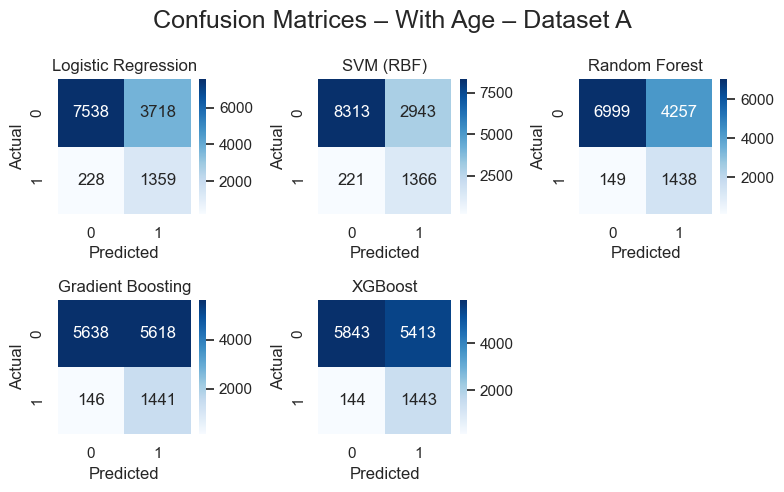

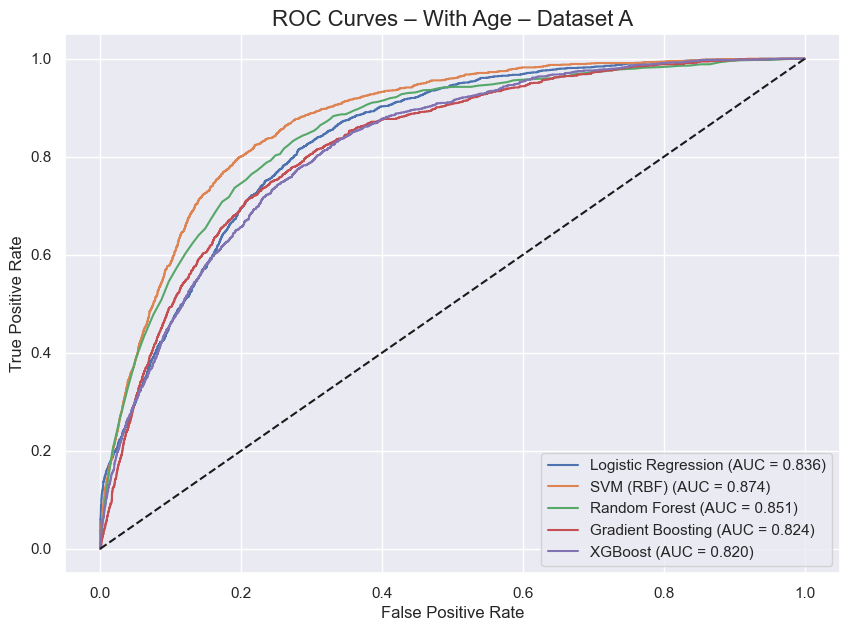


==================== With Age – Dataset B ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.68      0.80      9380
           1       0.27      0.86      0.41      1322

    accuracy                           0.70     10702
   macro avg       0.62      0.77      0.61     10702
weighted avg       0.89      0.70      0.75     10702


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      9380
           1       0.32      0.86      0.46      1322

    accuracy                           0.75     10702
   macro avg       0.65      0.80      0.65     10702
weighted avg       0.89      0.75      0.79     10702


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.61      0.76      9380
           1       0.25   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:50:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


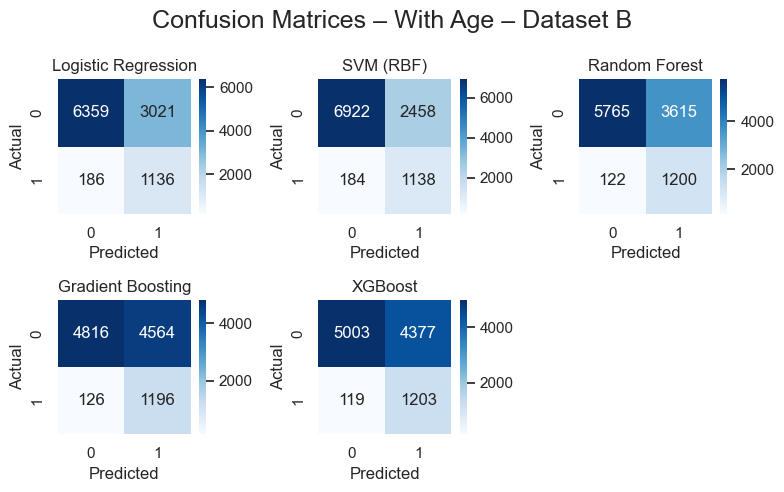

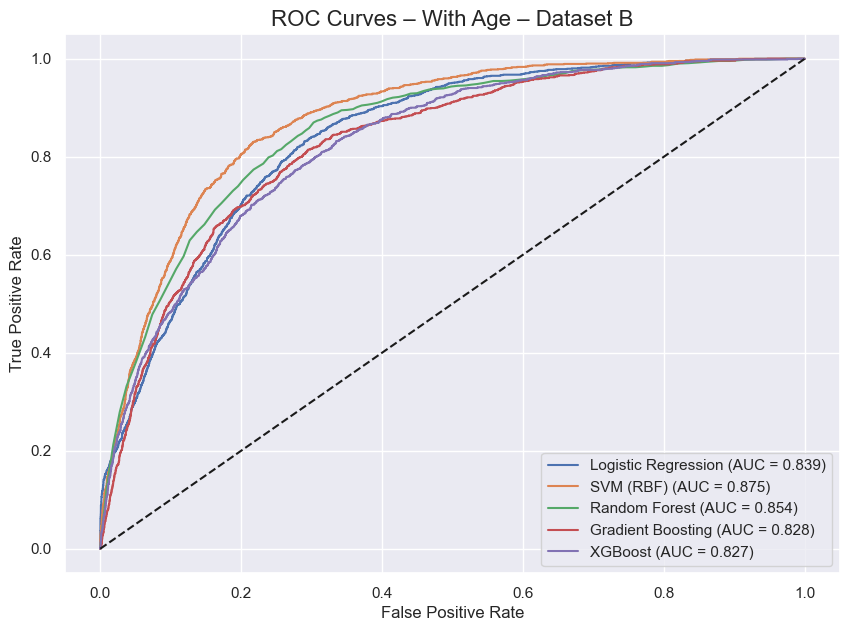


==================== With Age – Dataset C ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      7504
           1       0.27      0.85      0.41      1058

    accuracy                           0.69      8562
   macro avg       0.62      0.76      0.60      8562
weighted avg       0.88      0.69      0.75      8562


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      7504
           1       0.31      0.86      0.46      1058

    accuracy                           0.75      8562
   macro avg       0.64      0.80      0.65      8562
weighted avg       0.89      0.75      0.79      8562


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.61      0.75      7504
           1       0.25   

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:50:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


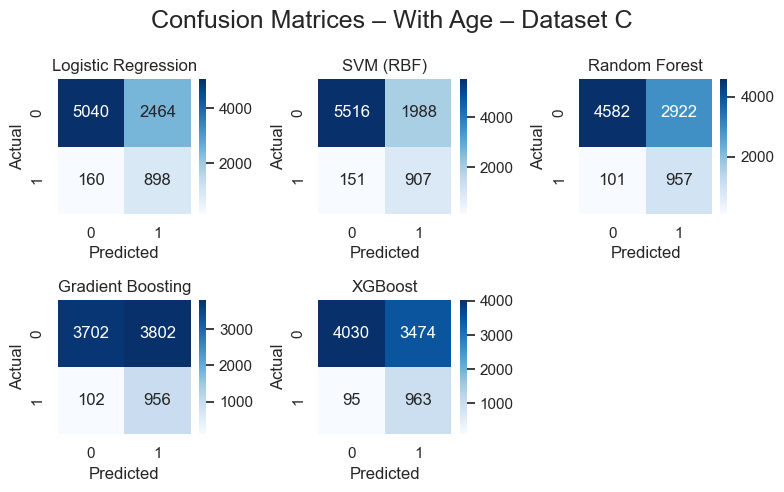

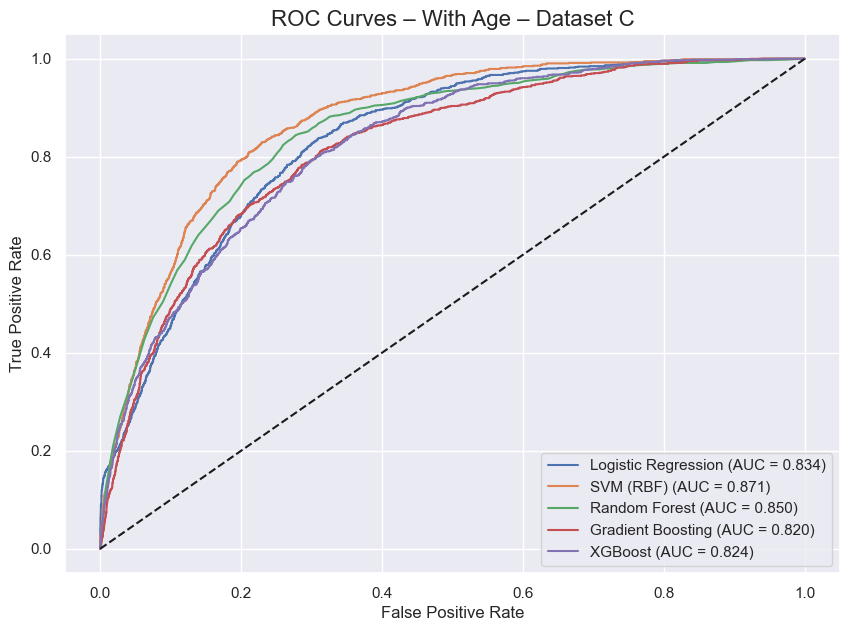

In [59]:
# Testing
results_A_with_age = evaluate_models(
    x_train_A, x_test_A, y_train_A, y_test_A,
    title="With Age – Dataset A"
)

results_B_with_age = evaluate_models(
    x_train_B, x_test_B, y_train_B, y_test_B,
    title="With Age – Dataset B"
)

results_C_with_age = evaluate_models(
    x_train_C, x_test_C, y_train_C, y_test_C,
    title="With Age – Dataset C"
)


==================== Without Age – Dataset A ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79     11256
           1       0.27      0.86      0.41      1587

    accuracy                           0.69     12843
   macro avg       0.62      0.76      0.60     12843
weighted avg       0.88      0.69      0.75     12843


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     11256
           1       0.31      0.85      0.45      1587

    accuracy                           0.75     12843
   macro avg       0.64      0.79      0.64     12843
weighted avg       0.89      0.75      0.79     12843


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.62      0.76     11256
           1       0.25

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:51:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


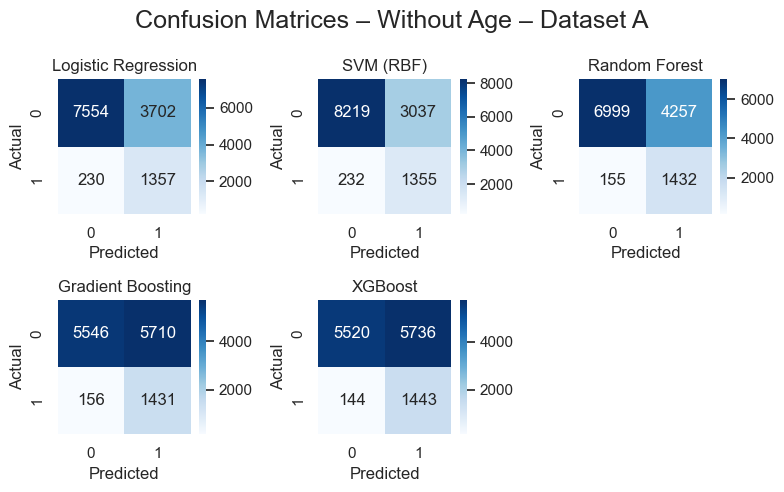

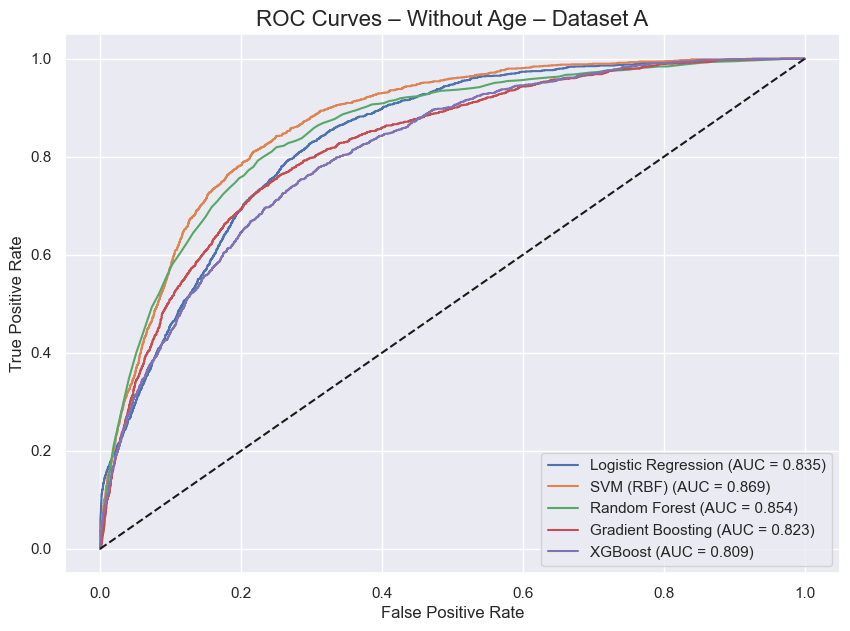


==================== Without Age – Dataset B ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      9380
           1       0.27      0.85      0.41      1322

    accuracy                           0.69     10702
   macro avg       0.62      0.76      0.60     10702
weighted avg       0.88      0.69      0.75     10702


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83      9380
           1       0.31      0.86      0.45      1322

    accuracy                           0.75     10702
   macro avg       0.64      0.79      0.64     10702
weighted avg       0.89      0.75      0.79     10702


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.62      0.76      9380
           1       0.25

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


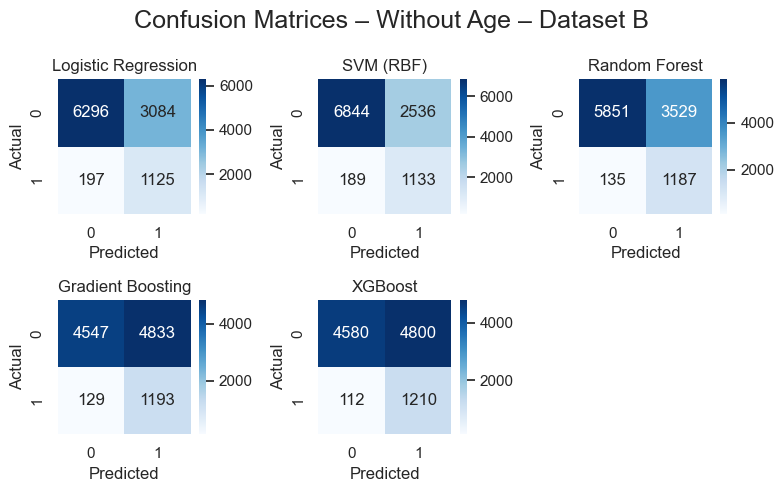

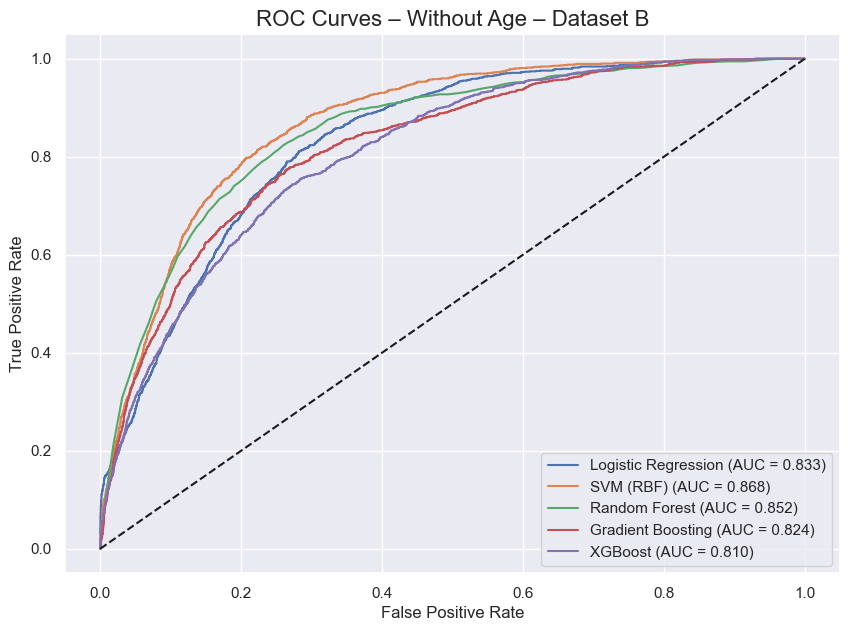


==================== Without Age – Dataset C ====================


- Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      7504
           1       0.26      0.84      0.40      1058

    accuracy                           0.69      8562
   macro avg       0.62      0.76      0.60      8562
weighted avg       0.88      0.69      0.74      8562


- Model: SVM (RBF)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83      7504
           1       0.30      0.85      0.45      1058

    accuracy                           0.74      8562
   macro avg       0.64      0.79      0.64      8562
weighted avg       0.89      0.74      0.78      8562


- Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.60      0.75      7504
           1       0.24

C:\Users\XPRISTO\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


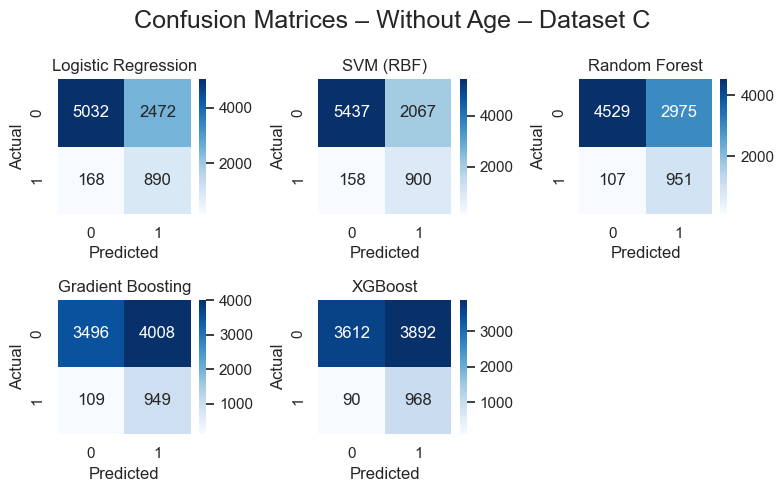

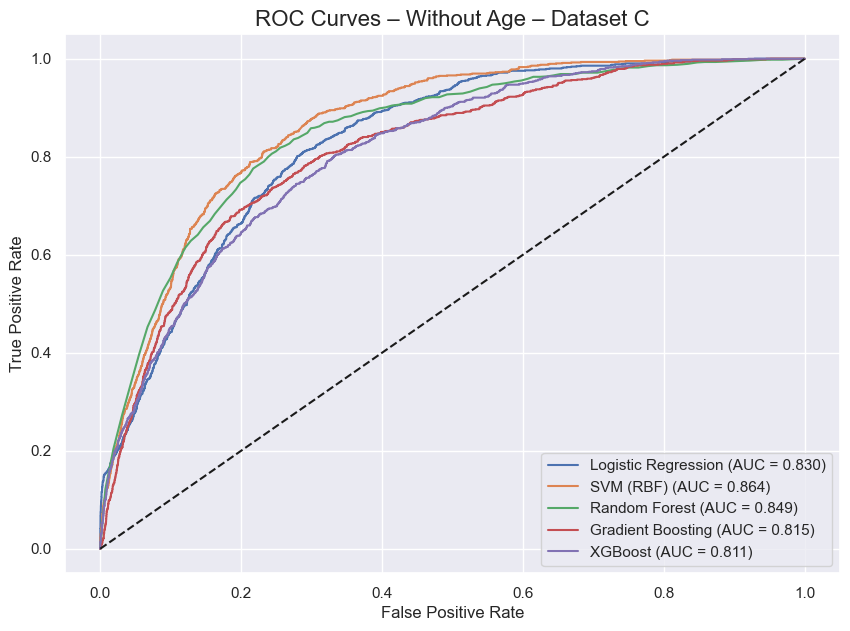

In [60]:
# Testing
results_A_with_age = evaluate_models(
    x_train_A1, x_test_A1, y_train_A1, y_test_A1,
    title="Without Age – Dataset A"
)

results_B_with_age = evaluate_models(
    x_train_B1, x_test_B1, y_train_B1, y_test_B1,
    title="Without Age – Dataset B"
)

results_C_with_age = evaluate_models(
    x_train_C1, x_test_C1, y_train_C1, y_test_C1,
    title="Without Age – Dataset C"
)